## Cell 1 — Mount Drive & Set Paths

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

DATAROOT   = '/content/drive/MyDrive/nuscenes'
MODEL_DIR  = '/content/drive/MyDrive/BEV Model'
WEIGHTS    = f'{MODEL_DIR}/bev_model_final2.pth'
CFG_PATH   = f'{MODEL_DIR}/bev_cfg.pkl'
OUT_DIR    = '/content/eval_outputs'
os.makedirs(OUT_DIR, exist_ok=True)

# Quick sanity check
print('nuScenes exists :', os.path.isdir(DATAROOT))
print('Weights exist   :', os.path.isfile(WEIGHTS))
print('Config exists   :', os.path.isfile(CFG_PATH))
print('Output dir      :', OUT_DIR)

Mounted at /content/drive
nuScenes exists : True
Weights exist   : True
Config exists   : True
Output dir      : /content/eval_outputs


## Cell 2 — Install Dependencies

In [ ]:
!pip uninstall -y numpy
!pip install numpy==1.26.4

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 69.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which 

In [ ]:
!pip install --upgrade --force-reinstall --no-cache-dir \
numpy==1.26.4 \
scipy==1.11.4 \
torch==2.2.2 \
torchvision==0.17.2 \
torchaudio==2.2.2 \
nuscenes-devkit pyquaternion timm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 17.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 144.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 262.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 246.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 138.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 157.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 109.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 118.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 106.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Cell 3 — Imports & Config

In [ ]:
import os
import pickle
import random
from dataclasses import dataclass, field
from typing import List

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from PIL import Image
from pyquaternion import Quaternion
from scipy.ndimage import binary_dilation
from torch.utils.data import DataLoader, Dataset

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    import subprocess
    result = subprocess.run(['nvidia-smi','--query-gpu=name,memory.total','--format=csv,noheader'],
                            capture_output=True, text=True)
    print(f'GPU    : {result.stdout.strip()}')

Device : cpu


## Cell 4 — Load Config from .pkl

In [ ]:
# ── Config dataclass (must match training exactly)
@dataclass
class Config:
    dataroot: str = '.'
    version:  str = 'v1.0-mini'
    img_h: int = 224
    img_w: int = 480
    x_bound: List[float] = field(default_factory=lambda: [-50.0, 50.0, 0.5])
    y_bound: List[float] = field(default_factory=lambda: [-50.0, 50.0, 0.5])
    z_bound: List[float] = field(default_factory=lambda: [ -3.0,  1.0, 4.0])
    d_bound: List[float] = field(default_factory=lambda: [1.0, 49.0, 2.0])
    batch_size:   int   = 8
    num_workers:  int   = 8
    max_epochs:   int   = 50
    lr:           float = 3e-4
    weight_decay: float = 1e-4
    pos_weight:   float = 12.0
    wandb_project: str  = 'nuscenes-bev'

    @property
    def bev_h(self): return int((self.y_bound[1]-self.y_bound[0])/self.y_bound[2])
    @property
    def bev_w(self): return int((self.x_bound[1]-self.x_bound[0])/self.x_bound[2])


# ── Load saved config ──────────────────────────────────────────────────────
with open("/content/drive/MyDrive/BEV Model/bev_cfg.pkl", 'rb') as f:
    cfg = pickle.load(f)
DATAROOT = '/content/drive/MyDrive/nuscenes'
# Override paths for this session
cfg.dataroot   = DATAROOT
cfg.batch_size = 8
cfg.num_workers = 8

print('Config loaded successfully!')
print(f'  nuScenes version : {cfg.version}')
print(f'  BEV grid         : {cfg.bev_h} x {cfg.bev_w} cells  ({cfg.y_bound[2]}m/cell)')
print(f'  Image size       : {cfg.img_h} x {cfg.img_w}')
print(f'  X range          : {cfg.x_bound[0]}m → {cfg.x_bound[1]}m')
print(f'  Y range          : {cfg.y_bound[0]}m → {cfg.y_bound[1]}m')
D = int((cfg.d_bound[1]-cfg.d_bound[0])/cfg.d_bound[2])
print(f'  Depth bins       : {D}')

Config loaded successfully!
  nuScenes version : v1.0-mini
  BEV grid         : 200 x 200 cells  (0.5m/cell)
  Image size       : 224 x 480
  X range          : -50.0m → 50.0m
  Y range          : -50.0m → 50.0m
  Depth bins       : 24


## Cell 5 — Dataset

In [ ]:
CAMERAS = [
    'CAM_FRONT', 'CAM_FRONT_RIGHT', 'CAM_FRONT_LEFT',
    'CAM_BACK',  'CAM_BACK_RIGHT',  'CAM_BACK_LEFT',
]
_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)


class NuScenesDataset(Dataset):
    def __init__(self, cfg, split):
        from nuscenes.nuscenes import NuScenes
        from nuscenes.utils.splits import create_splits_scenes
        self.cfg   = cfg
        self.split = split
        self.img_h = cfg.img_h
        self.img_w = cfg.img_w
        self.augment = False  # always False at eval time

        x_min, x_max, dx = cfg.x_bound
        y_min, y_max, dy = cfg.y_bound
        self.bev_w = int((x_max - x_min) / dx)
        self.bev_h = int((y_max - y_min) / dy)

        print(f'Loading nuScenes {cfg.version} [{split}]...')
        self.nusc = NuScenes(version=cfg.version, dataroot=cfg.dataroot, verbose=False)

        split_scenes = set(create_splits_scenes()[split])
        self.samples = []
        for scene in self.nusc.scene:
            if scene['name'] not in split_scenes:
                continue
            token = scene['first_sample_token']
            while token:
                s = self.nusc.get('sample', token)
                self.samples.append(s)
                token = s['next']
        print(f'  -> {len(self.samples)} samples')

    def __len__(self): return len(self.samples)

    def _cam_to_ego_matrix(self, cs):
        R = Quaternion(cs['rotation']).rotation_matrix.astype(np.float32)
        t = np.array(cs['translation'], dtype=np.float32)
        T = np.eye(4, dtype=np.float32)
        T[:3,:3] = R; T[:3,3] = t
        return T

    def get_camera_info(self, sample):
        imgs, Ks, T_c2e = [], [], []
        for cam in CAMERAS:
            sd  = self.nusc.get('sample_data', sample['data'][cam])
            cs  = self.nusc.get('calibrated_sensor', sd['calibrated_sensor_token'])
            img = Image.open(
                os.path.join(self.nusc.dataroot, sd['filename'])
            ).convert('RGB')
            ow, oh = img.size
            img = img.resize((self.img_w, self.img_h), Image.Resampling.BILINEAR)
            img_t = (TF.to_tensor(img) - _MEAN) / _STD
            imgs.append(img_t)
            K = np.array(cs['camera_intrinsic'], dtype=np.float32)
            K[0,:] *= self.img_w / ow
            K[1,:] *= self.img_h / oh
            Ks.append(torch.from_numpy(K))
            T_c2e.append(torch.from_numpy(self._cam_to_ego_matrix(cs)))
        return torch.stack(imgs), torch.stack(Ks), torch.stack(T_c2e)

    def get_bev_occupancy(self, sample):
        from nuscenes.utils.data_classes import LidarPointCloud
        sd  = self.nusc.get('sample_data', sample['data']['LIDAR_TOP'])
        cs  = self.nusc.get('calibrated_sensor', sd['calibrated_sensor_token'])
        pc  = LidarPointCloud.from_file(
            os.path.join(self.nusc.dataroot, sd['filename'])
        )
        pc.rotate(Quaternion(cs['rotation']).rotation_matrix)
        pc.translate(np.array(cs['translation']))
        pts = pc.points[:3].T
        xb, yb, zb = self.cfg.x_bound, self.cfg.y_bound, self.cfg.z_bound
        mask = ((pts[:,0]>=xb[0])&(pts[:,0]<xb[1])&
                (pts[:,1]>=yb[0])&(pts[:,1]<yb[1])&
                (pts[:,2]>=zb[0])&(pts[:,2]<zb[1]))
        pts = pts[mask]
        ix  = np.clip(((pts[:,0]-xb[0])/xb[2]).astype(int), 0, self.bev_w-1)
        iy  = np.clip(((pts[:,1]-yb[0])/yb[2]).astype(int), 0, self.bev_h-1)
        occ = np.zeros((self.bev_h, self.bev_w), dtype=np.float32)
        occ[iy, ix] = 1.0
        return torch.from_numpy(occ).unsqueeze(0)

    def __getitem__(self, idx):
        s = self.samples[idx]
        imgs, K, T = self.get_camera_info(s)
        bev = self.get_bev_occupancy(s)
        return {'imgs': imgs, 'intrinsics': K, 'cam_to_ego': T, 'bev': bev}


print('Dataset class defined ✅')

Dataset class defined ✅


## Cell 6 — Model (LSS)

In [ ]:
import timm

# ── Backbone ──────────────────────────────────────────────────────────────────
class ImageBackbone(nn.Module):
    def __init__(self, model_name='efficientnet_b0', out_channels=64):
        super().__init__()
        self.encoder = timm.create_model(
            model_name, pretrained=False, features_only=True, out_indices=(1,2,3)
        )
        feat_ch = sum(self.encoder.feature_info.channels())
        self.reduce = nn.Sequential(
            nn.Conv2d(feat_ch, out_channels*2, 1, bias=False),
            nn.BatchNorm2d(out_channels*2), nn.ReLU(True),
            nn.Conv2d(out_channels*2, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(True),
        )
        self.out_channels = out_channels

    def forward(self, x):
        feats = self.encoder(x)
        h, w  = feats[0].shape[2:]
        feats = [F.interpolate(f,(h,w),mode='bilinear',align_corners=False) for f in feats]
        return self.reduce(torch.cat(feats, dim=1))


# ── Depth Head (ASPP) ────────────────────────────────────────────────────────
class DepthHead(nn.Module):
    def __init__(self, in_ch, D):
        super().__init__()
        mid = in_ch // 2
        self.b0 = nn.Sequential(nn.Conv2d(in_ch,mid,1,bias=False),nn.BatchNorm2d(mid),nn.ReLU(True))
        self.b1 = nn.Sequential(nn.Conv2d(in_ch,mid,3,padding=2,dilation=2,bias=False),nn.BatchNorm2d(mid),nn.ReLU(True))
        self.b2 = nn.Sequential(nn.Conv2d(in_ch,mid,3,padding=4,dilation=4,bias=False),nn.BatchNorm2d(mid),nn.ReLU(True))
        self.b3 = nn.Sequential(nn.Conv2d(in_ch,mid,3,padding=8,dilation=8,bias=False),nn.BatchNorm2d(mid),nn.ReLU(True))
        self.fuse = nn.Sequential(
            nn.Conv2d(mid*4,in_ch,1,bias=False),nn.BatchNorm2d(in_ch),nn.ReLU(True),
            nn.Conv2d(in_ch,D,1),
        )
    def forward(self, x):
        x = torch.cat([self.b0(x),self.b1(x),self.b2(x),self.b3(x)], dim=1)
        return self.fuse(x).softmax(dim=1)


# ── LSS View Transformer ──────────────────────────────────────────────────────
class LSSViewTransformer(nn.Module):
    def __init__(self, feat_ch, bev_ch, d_bound, x_bound, y_bound, z_bound, img_h, img_w):
        super().__init__()
        self.x_bound, self.y_bound, self.z_bound = x_bound, y_bound, z_bound
        d_arr  = np.arange(d_bound[0], d_bound[1], d_bound[2], dtype=np.float32)
        self.D = len(d_arr)
        self.register_buffer('d_values', torch.from_numpy(d_arr))
        self.bev_h  = int((y_bound[1]-y_bound[0])/y_bound[2])
        self.bev_w  = int((x_bound[1]-x_bound[0])/x_bound[2])
        self.feat_h = img_h // 4
        self.feat_w = img_w // 4
        ys = torch.linspace(0, self.feat_h-1, self.feat_h)
        xs = torch.linspace(0, self.feat_w-1, self.feat_w)
        yy, xx = torch.meshgrid(ys, xs, indexing='ij')
        pg = torch.stack([xx, yy, torch.ones_like(xx)], -1)
        self.register_buffer('pixel_grid', pg)
        self.depth_head = DepthHead(feat_ch, self.D)
        self.bev_agg = nn.Sequential(
            nn.Conv2d(feat_ch, bev_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(bev_ch), nn.ReLU(True),
        )

    def get_geometry(self, intrinsics, cam_to_ego):
        B, N    = intrinsics.shape[:2]
        D, H, W = self.D, self.feat_h, self.feat_w
        K_inv   = torch.inverse(intrinsics)
        pg_flat = self.pixel_grid.reshape(H*W, 3).T
        pg_flat = pg_flat.unsqueeze(0).expand(B*N, 3, H*W)
        rays    = torch.bmm(K_inv.reshape(B*N,3,3), pg_flat)
        rays    = rays.permute(0,2,1).reshape(B,N,H,W,3).unsqueeze(2)
        d       = self.d_values.view(1,1,D,1,1,1)
        p_cam   = rays * d
        ones    = torch.ones(*p_cam.shape[:-1], 1, device=intrinsics.device)
        p_h     = torch.cat([p_cam, ones], -1)
        p_flat  = p_h.reshape(B*N, D*H*W, 4).permute(0,2,1)
        p_ego   = torch.bmm(cam_to_ego.reshape(B*N,4,4), p_flat)
        return  p_ego[:,:3].permute(0,2,1).reshape(B,N,D,H,W,3)

    def voxel_pooling(self, p_ego, features, depth_probs):
        B, N, D, H, W, _ = p_ego.shape
        C = features.shape[-1]
        x_min, _, dx = self.x_bound
        y_min, _, dy = self.y_bound
        ix    = ((p_ego[...,0]-x_min)/dx).long()
        iy    = ((p_ego[...,1]-y_min)/dy).long()
        valid = (ix>=0)&(ix<self.bev_w)&(iy>=0)&(iy<self.bev_h)
        feat_exp = features.unsqueeze(2).expand(B,N,D,H,W,C)
        weighted = (feat_exp * depth_probs.unsqueeze(-1)).contiguous()
        bev    = torch.zeros(B, C, self.bev_h, self.bev_w, device=features.device)
        b_idx  = torch.arange(B, device=features.device).view(B,1,1,1,1).expand(B,N,D,H,W)
        flat   = (b_idx * self.bev_h * self.bev_w + iy * self.bev_w + ix)
        v      = valid.reshape(-1)
        flat_v = flat.reshape(-1)[v]
        fw     = weighted.reshape(-1, C)[v]
        bev.view(B*self.bev_h*self.bev_w, C).scatter_add_(
            0, flat_v.unsqueeze(1).expand(-1,C), fw)
        return bev.view(B, C, self.bev_h, self.bev_w)

    def forward(self, features, intrinsics, cam_to_ego):
        B, N, C, H, W = features.shape
        p_ego       = self.get_geometry(intrinsics, cam_to_ego)
        depth_probs = self.depth_head(features.view(B*N,C,H,W)).view(B,N,self.D,H,W)
        feats_hwc   = features.permute(0,1,3,4,2)
        bev         = self.voxel_pooling(p_ego, feats_hwc, depth_probs)
        return self.bev_agg(bev)


# ── BEV Decoder ───────────────────────────────────────────────────────────────
class BEVDecoder(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(in_ch,in_ch*2,3,padding=1,bias=False),nn.BatchNorm2d(in_ch*2),nn.ReLU(True),
            nn.Conv2d(in_ch*2,in_ch*2,3,padding=1,bias=False),nn.BatchNorm2d(in_ch*2),nn.ReLU(True),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(in_ch*2,in_ch,3,padding=1,bias=False),nn.BatchNorm2d(in_ch),nn.ReLU(True),
            nn.Conv2d(in_ch,in_ch,3,padding=1,bias=False),nn.BatchNorm2d(in_ch),nn.ReLU(True),
        )
        self.skip = nn.Conv2d(in_ch*2, in_ch, 1, bias=False)
        self.head = nn.Conv2d(in_ch, 1, 1)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x) + self.skip(x)
        return self.head(x)


# ── Full Model ────────────────────────────────────────────────────────────────
class BEVModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        C = 64
        self.backbone         = ImageBackbone('efficientnet_b0', out_channels=C)
        self.view_transformer = LSSViewTransformer(
            feat_ch=C, bev_ch=C,
            d_bound=cfg.d_bound, x_bound=cfg.x_bound,
            y_bound=cfg.y_bound, z_bound=cfg.z_bound,
            img_h=cfg.img_h,    img_w=cfg.img_w,
        )
        self.decoder = BEVDecoder(C)

    def forward(self, imgs, intrinsics, cam_to_ego):
        B, N, C, H, W = imgs.shape
        feats = self.backbone(imgs.view(B*N, C, H, W))
        _, fC, fH, fW = feats.shape
        feats = feats.view(B, N, fC, fH, fW)
        bev   = self.view_transformer(feats, intrinsics, cam_to_ego)
        return self.decoder(bev)


print('Model classes defined ✅')

Model classes defined ✅


## Cell 7 — Load Weights

In [ ]:
model = BEVModel(cfg).to(DEVICE)
WEIGHTS = "/content/drive/MyDrive/BEV Model/bev_model_final2.pth"
state = torch.load(WEIGHTS, map_location=DEVICE, weights_only=True)
model.load_state_dict(state)
model.eval()

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'✅ Weights loaded from: {WEIGHTS}')
print(f'   Parameters : {n_params:.2f}M')

✅ Weights loaded from: /content/drive/MyDrive/BEV Model/bev_model_final2.pth
   Parameters : 4.07M


## Cell 8 — Build Val DataLoader

In [ ]:
EVAL_SPLIT = 'val'   # change to 'train' or 'mini_val' if needed

val_ds = NuScenesDataset(cfg, split=EVAL_SPLIT)
val_dl = DataLoader(
    val_ds,
    batch_size  = cfg.batch_size,
    shuffle     = False,
    num_workers = cfg.num_workers,
    pin_memory  = (DEVICE == 'cuda'),
)
print(f'\nDataLoader ready: {len(val_ds)} samples, batch_size={cfg.batch_size}')

Loading nuScenes v1.0-mini [val]...
  -> 162 samples

DataLoader ready: 162 samples, batch_size=8


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


## Cell 9 — Evaluation (IoU + Distance-weighted Error)

In [ ]:
def make_distance_weight(cfg, device):
    """1/r weight map — gives higher penalty to errors close to ego-vehicle."""
    x_min, x_max, dx = cfg.x_bound
    y_min, y_max, dy = cfg.y_bound
    xs = torch.linspace(x_min+dx/2, x_max-dx/2, cfg.bev_w)
    ys = torch.linspace(y_min+dy/2, y_max-dy/2, cfg.bev_h)
    yy, xx = torch.meshgrid(ys, xs, indexing='ij')
    dist = (xx**2 + yy**2).sqrt().clamp(min=1.0)
    w = 1.0 / dist
    w = w / w.mean()   # normalise so mean weight = 1
    return w.to(device)  # (bev_h, bev_w)


def evaluate_model(model, val_dl, cfg, device, thresholds=None, verbose=True):
    if thresholds is None:
        thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]

    model.eval()
    dist_w = make_distance_weight(cfg, device)  # (H, W)
    results = {}

    for thresh in thresholds:
        tp = fp = fn = 0
        dw_err = 0.0
        n_pixels = 0

        with torch.no_grad():
            for batch in val_dl:
                batch  = {k: v.to(device) for k, v in batch.items()}
                logits = model(batch['imgs'], batch['intrinsics'], batch['cam_to_ego'])
                probs  = logits.sigmoid()
                pred   = (probs > thresh).float()
                target = batch['bev']

                tp += (pred * target).sum().item()
                fp += (pred * (1 - target)).sum().item()
                fn += ((1 - pred) * target).sum().item()

                # Distance-weighted error
                err      = (pred - target).abs()          # (B, 1, H, W)
                dw_err  += (err * dist_w).sum().item()
                n_pixels += err.numel()

        iou  = tp / (tp + fp + fn + 1e-6)
        prec = tp / (tp + fp + 1e-6)
        rec  = tp / (tp + fn + 1e-6)
        f1   = 2 * prec * rec / (prec + rec + 1e-6)
        dwe  = dw_err / n_pixels

        results[thresh] = dict(iou=iou, precision=prec, recall=rec, f1=f1, dw_error=dwe)

        if verbose:
            print(f'thresh={thresh:.2f} | IoU={iou*100:5.2f}% | '
                  f'Prec={prec*100:5.2f}% | Rec={rec*100:5.2f}% | '
                  f'F1={f1*100:5.2f}% | DW-Err={dwe:.5f}')

    best_t = max(results, key=lambda t: results[t]['iou'])
    best   = results[best_t]

    print(f"\n{'='*62}")
    print(f" Best threshold      : {best_t}")
    print(f" Occupancy IoU       : {best['iou']*100:.2f}%")
    print(f" Precision           : {best['precision']*100:.2f}%")
    print(f" Recall              : {best['recall']*100:.2f}%")
    print(f" F1                  : {best['f1']*100:.2f}%")
    print(f" Distance-weighted   : {best['dw_error']:.6f}")
    print(f"{'='*62}")

    return results, best_t


# ── Run ───────────────────────────────────────────────────────────────────────
print(f'Evaluating on [{EVAL_SPLIT}] split ({len(val_ds)} samples)...\n')
results, best_thresh = evaluate_model(model, val_dl, cfg, DEVICE)

Evaluating on [val] split (162 samples)...



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


thresh=0.30 | IoU=20.13% | Prec=21.63% | Rec=74.31% | F1=33.51% | DW-Err=0.25220
thresh=0.35 | IoU=23.02% | Prec=25.54% | Rec=69.98% | F1=37.42% | DW-Err=0.21779
thresh=0.40 | IoU=25.89% | Prec=29.99% | Rec=65.45% | F1=41.13% | DW-Err=0.18815
thresh=0.45 | IoU=28.57% | Prec=35.07% | Rec=60.66% | F1=44.45% | DW-Err=0.16244
thresh=0.50 | IoU=30.80% | Prec=40.88% | Rec=55.53% | F1=47.09% | DW-Err=0.14039
thresh=0.55 | IoU=32.24% | Prec=47.27% | Rec=50.35% | F1=48.76% | DW-Err=0.12250
thresh=0.60 | IoU=32.44% | Prec=53.47% | Rec=45.21% | F1=48.99% | DW-Err=0.10975
thresh=0.65 | IoU=31.50% | Prec=59.03% | Rec=40.31% | F1=47.91% | DW-Err=0.10139
thresh=0.70 | IoU=29.28% | Prec=63.80% | Rec=35.11% | F1=45.29% | DW-Err=0.09767
thresh=0.75 | IoU=25.84% | Prec=68.58% | Rec=29.31% | F1=41.07% | DW-Err=0.09709
thresh=0.80 | IoU=21.09% | Prec=74.89% | Rec=22.70% | F1=34.84% | DW-Err=0.09942

 Best threshold      : 0.6
 Occupancy IoU       : 32.44%
 Precision           : 53.47%
 Recall              

## Cell 10 — IoU vs Threshold Plot

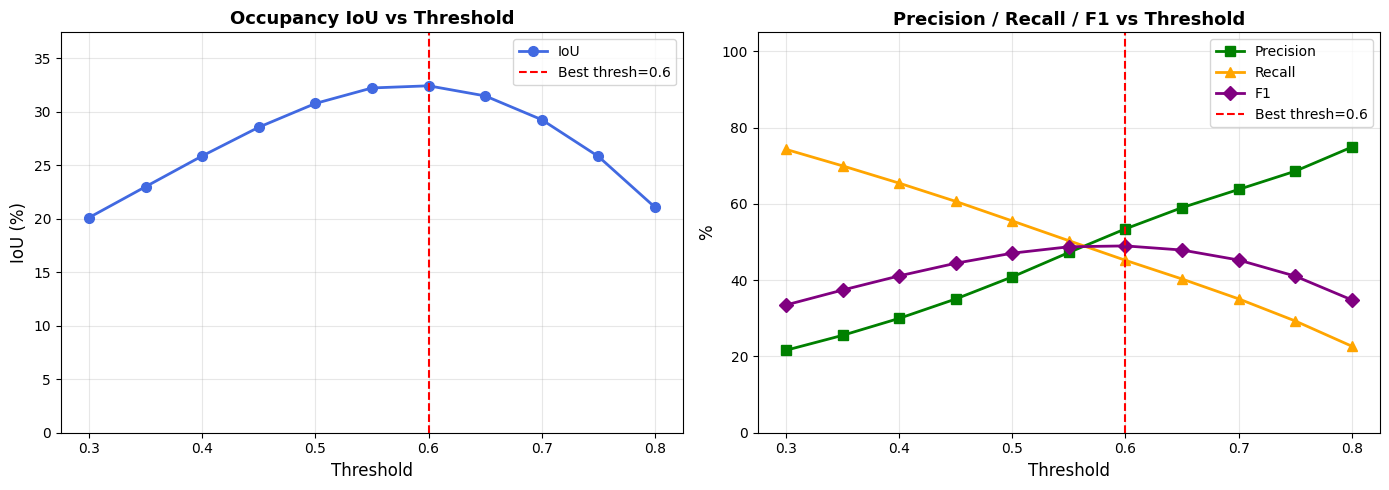

Plot saved to /content/drive/MyDrive/iouvth_plots/metrics_vs_threshold.png


In [ ]:
thresholds = sorted(results.keys())
ious  = [results[t]['iou']*100     for t in thresholds]
precs = [results[t]['precision']*100 for t in thresholds]
recs  = [results[t]['recall']*100  for t in thresholds]
f1s   = [results[t]['f1']*100      for t in thresholds]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: IoU curve
ax = axes[0]
ax.plot(thresholds, ious, 'o-', color='royalblue', linewidth=2, markersize=7, label='IoU')
ax.axvline(best_thresh, color='red', linestyle='--', label=f'Best thresh={best_thresh}')
ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('IoU (%)', fontsize=12)
ax.set_title('Occupancy IoU vs Threshold', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_ylim(0, max(ious)+5)

# Right: Prec / Rec / F1 curves
ax = axes[1]
ax.plot(thresholds, precs, 's-', color='green',  linewidth=2, markersize=7, label='Precision')
ax.plot(thresholds, recs,  '^-', color='orange', linewidth=2, markersize=7, label='Recall')
ax.plot(thresholds, f1s,   'D-', color='purple', linewidth=2, markersize=7, label='F1')
ax.axvline(best_thresh, color='red', linestyle='--', label=f'Best thresh={best_thresh}')
ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('%', fontsize=12)
ax.set_title('Precision / Recall / F1 vs Threshold', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)

plt.tight_layout()
plot_path = "/content/drive/MyDrive/iouvth_plots/metrics_vs_threshold.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved to {plot_path}')

## Cell 11 — BEV Visualisation (Pred vs GT)

In [ ]:
import os
import matplotlib.pyplot as plt
import torch

VIS_SAMPLES = 8
OUT_DIR = "/content/drive/MyDrive/predvgt"
os.makedirs(OUT_DIR, exist_ok=True)

model.eval()
saved_paths = []

with torch.no_grad():
    for i in range(VIS_SAMPLES):
        sample = val_ds[i]

        batch = {
            k: v.unsqueeze(0).to(DEVICE)
            for k, v in sample.items()
        }

        logits = model(batch['imgs'], batch['intrinsics'], batch['cam_to_ego'])

        pred_p = logits.sigmoid().squeeze().cpu().numpy()
        pred_b = (logits.sigmoid() > best_thresh).float().squeeze().cpu().numpy()
        gt = sample['bev'].squeeze().numpy()

        # IoU
        tp = (pred_b * gt).sum()
        fp = (pred_b * (1 - gt)).sum()
        fn = ((1 - pred_b) * gt).sum()
        sample_iou = tp / (tp + fp + fn + 1e-6)

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        axes[0].imshow(pred_p, cmap='hot', origin='lower', vmin=0, vmax=1)
        axes[0].set_title('Predicted Probability')

        axes[1].imshow(pred_b, cmap='hot', origin='lower', vmin=0, vmax=1)
        axes[1].set_title(f'Binary (thr={best_thresh})')

        axes[2].imshow(gt, cmap='hot', origin='lower', vmin=0, vmax=1)
        axes[2].set_title('Ground Truth')

        fig.suptitle(f'Sample {i} | IoU = {sample_iou*100:.2f}%')

        plt.tight_layout()

        path = os.path.join(OUT_DIR, f"bev_sample_{i:03d}.png")
        plt.savefig(path, dpi=130, bbox_inches='tight')
        plt.close(fig)  # IMPORTANT: prevents memory leak

        saved_paths.append(path)

print(f"\nSaved {len(saved_paths)} visualisations to {OUT_DIR}/")


Saved 8 visualisations to /content/drive/MyDrive/predvgt/


## Cell 12 — Save Results Summary to Drive

In [ ]:
import json, shutil

# ── Save JSON summary ─────────────────────────────────────────────────────────
summary = {
    'model_weights'  : WEIGHTS,
    'eval_split'     : EVAL_SPLIT,
    'n_samples'      : len(val_ds),
    'best_threshold' : best_thresh,
    'best_iou_%'     : round(results[best_thresh]['iou']*100, 3),
    'best_precision_%': round(results[best_thresh]['precision']*100, 3),
    'best_recall_%'  : round(results[best_thresh]['recall']*100, 3),
    'best_f1_%'      : round(results[best_thresh]['f1']*100, 3),
    'best_dw_error'  : round(results[best_thresh]['dw_error'], 6),
    'all_thresholds' : {
        str(t): {
            'iou_%'      : round(v['iou']*100, 3),
            'precision_%': round(v['precision']*100, 3),
            'recall_%'   : round(v['recall']*100, 3),
            'f1_%'       : round(v['f1']*100, 3),
            'dw_error'   : round(v['dw_error'], 6),
        }
        for t, v in results.items()
    }
}

json_path = f'{OUT_DIR}/eval_results.json'
with open(json_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f'Results JSON  : {json_path}')

# ── Copy everything to Drive ──────────────────────────────────────────────────
MODEL_DIR = "/content/drive/MyDrive/BEV Model"
DRIVE_OUT = f'{MODEL_DIR}/eval_outputs'
os.makedirs(DRIVE_OUT, exist_ok=True)

for fname in os.listdir(OUT_DIR):
    src = os.path.join(OUT_DIR, fname)
    dst = os.path.join(DRIVE_OUT, fname)
    shutil.copy2(src, dst)

print(f'All outputs copied to Drive: {DRIVE_OUT}')
print('\n📊 Final Results:')
print(f"  Occupancy IoU        : {summary['best_iou_%']}%")
print(f"  Precision            : {summary['best_precision_%']}%")
print(f"  Recall               : {summary['best_recall_%']}%")
print(f"  F1                   : {summary['best_f1_%']}%")
print(f"  Distance-weighted Err: {summary['best_dw_error']}")
print(f"  Best threshold       : {summary['best_threshold']}")

Results JSON  : /content/drive/MyDrive/predvgt/eval_results.json
All outputs copied to Drive: /content/drive/MyDrive/BEV Model/eval_outputs

📊 Final Results:
  Occupancy IoU        : 32.444%
  Precision            : 53.467%
  Recall               : 45.21%
  F1                   : 48.993%
  Distance-weighted Err: 0.109755
  Best threshold       : 0.6
